### numpy, но сложнее

Настоящий мир сложнее, чем ряды чисел - иногда нужно работать с данными больших размерностей, например - двумерные. Мы видим такие наборы данных постоянно - картинки.

В директории есть картинка cat.png:

![cat.png](cat.png)

Хотя наши компьютеры отображают это как картинку, на самом деле они должны её как-то хранить. Делают они это, храня список списков из 64 рядов и 64 столбцов. Такой набор данных называется двумерным массивом - для любой пары чисел x и y от 0 до 63 включительно можно получить значение третьего числа, которое характеризует цвет по этим координатам (пиксель). Пиксель может принимать значения от 0 (белый цвет) до 1 (чёрный цвет). Всё между - оттенки серого.

Попробуем поизучать картинку:

In [ ]:
import matplotlib.pyplot as plt

arr = plt.imread("cat.png") # функция для получения двумерного массива из файла с картинкой

# Поизучаем:

print(len(arr)) # число строк в массиве
print(len(arr[0])) # число столбцов в массиве
print(arr.shape) # то же самое, но проще. Обратите внимание, что эту функцию мы уже использовали в прошлом ноутбуке!

print(arr[1]) # получение массива в ряду с индексом 1 (какой это ряд по счёту?)
print(arr[:, 1]) # получение массива в столбце с индексом 1

print(arr) # что во всём массиве лежит?


Такие двумерные массивы ведут себя так же, как и обычные numpy массивы, значит - их можно умножать, делить, складывать и делать любые другие математические операции, какие мы уже делали в прошлых ноутбуках.

Например:

In [ ]:
new_arr = 1 - arr

print(new_arr)

Вы могли заметить, что мы получили numpy-массив при помощи matplotlib (aka библиотеки для рисования картинок). Можно ли рисовать двумерные массивы? Да!

In [ ]:
plt.imshow(new_arr, cmap='gray')

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 1**</font>

Преобразовать картинку так, чтобы цвета стали более разрозненными - если цвет пикселя больше, чем 0.5 - он должен стать на 10% ближе к 1, если меньше, то он должен стать на 10% ближе к 0.

</div>

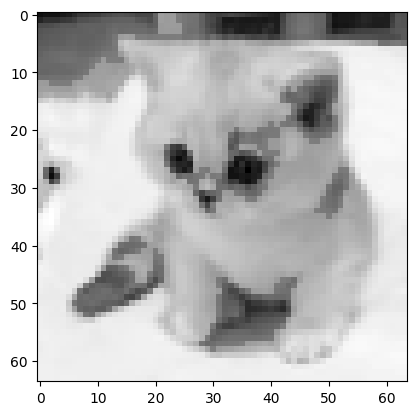

In [2]:
arr = plt.imread("cat.png")

new_arr = []
for row in arr:
    new_row = []
    for val in row:
        if val > 0.5:
            new_row.append(val + 0.1 * (1 - val))
        elif val < 0.5:
            new_row.append(val - 0.1 * val)
        else:
            new_row.append(val)
    new_arr.append(new_row)

plt.imshow(new_arr, cmap="gray")

### Свои двумерные массивы

Мы уже умеем создавать одномерные массивы:

```python
arr = np.array([1, 2, 3, 4])
```

Двумерные массивы создаются точно так же, но вместо простого списка нам нужно передать список списков:

In [ ]:
import numpy as np

arr2 = np.array([
    [1, 2, 3, 4],
    [2, 3, 4, 5], 
    [6, 7, 8, 9],
])

print(arr2.shape)
print(arr2)

Так же, как и одномерные массивы, мы можем создавать и двумерные массивы из константных значений:

In [ ]:
arr3 = np.zeros((4, 5)) # 4 строки, 5 столбцов
arr4 = np.ones((3, 10)) # 3 строки, 10 столбцов
arr5 = np.full((5, 5), 11) # 5 строк и 5 столбцов

print(arr3)
print(arr4)
print(arr5)

### Получение элементов

In [ ]:
data = np.random.randint(1, 10, (5, 7)) # двумерный массив из случайных чисел из 5 строк и 7 столбцов

print(data)

print(data[3]) # строка с индексом 3
print(data[3, 2]) # элемент из строки с индексом 3 и столбца с индексом 2
print(data[3, :]) # строка с индексом 3
print(data[3, :] == data[3])

print(data[:, 2]) # столбец с индексом 2


Срезы в двумерных массивах работают логически так же, как и в списках или одномернхы массивах, но вырезается соответствующая ось массива:

In [ ]:
print(data[1:4, 5]) # массив из значений строк с 1 по 3 в столбце в индексом 5
print(data[4, 1:4]) # как это читать?

print(data[1:4, 1:4])

Можно так же изменять данные по индексам:

In [ ]:
data[3, 4] = 1000

print(data)

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 2**</font>

Нарисовать карту функции $f(x, y) = sin(x) * cos(y)$ на промежутке $x \in [0, 2\pi]$, $y \in [0, 2\pi]$. На выходе должна быть картинка, нарисованная через `plt.imshow`, цвет каждого пикселя которой отражает значение функции в точке с соответствующим $x$ и $y$.

Сетку взять 64 на 64 пикселя.

<details>
  <summary>Подсказка</summary>
  
  Зная число строк и число столбцов, как присвоить значение каждому элементу массива в соответствии с функцией?
</details>
</div>

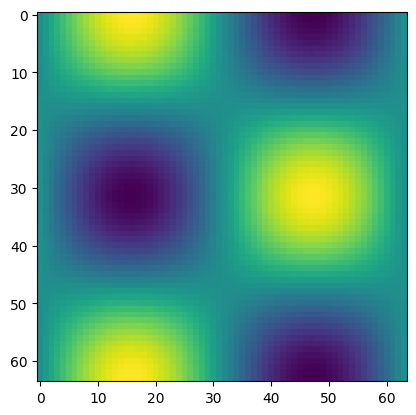

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 64)
y = np.linspace(0, 2 * np.pi, 64)

data = np.zeros((64, 64))
for i in range(64):
    for j in range(64):
        data[i, j] = np.sin(x[j]) * np.cos(y[i])

plt.imshow(data)

### Чуть-чуть статистики

Часто нам интересен не сам массив данных сам по себе, а какие-то его агрегированные параметры. Пример такого параметра - среднее. Когда нам нужно получить ответ на вопрос "а примерно вокруг какого значения собраны элементы массива?", мы можем его использовать. Есть много других интересных статистик, на которые мы сейчас посмотрим.

В этом ноутбуке будет только верхнеуровневое интуитивное представление этих параметров, настоящее обоснование проходят в курсе математической статистики.

В качестве затравки нарисуем распределение данных:

In [ ]:
import numpy as np

values = np.random.normal(loc=0.0, scale=1.0, size=500) # логнормальное распределение - распределение чисел, которое получается, если взять обычное нормальное распределение и возвести число Эйлера в степень каждого из этих значений

# добавим несколько явных выбросов
values = np.append(values, [-10, 10, 11, 10, 1])

# и нарисуем:
plt.hist(values, bins=30)
plt.yscale("log")
plt.show()


#### Стандартное отклонение

Это характеристика "насколько значения обычно отличаются от среднего". Формула:

Стандартное отклонение вычисляется по формуле:

$$
    \sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \overline{x})^2 }
$$

где $x_i$ — элементы массива, $\overline{x}$ — среднее значение, $N$ — количество элементов.

К счастью, на самим это считать надо крайне редко:

In [ ]:
mean = np.mean(values) # среднее
std = np.std(values) # стандартное отклонение

print(mean, std)

In [ ]:
plt.hist(values, bins=30)
plt.yscale("log")
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.axvline(mean - std, color='green', linestyle=':', label='Mean - Std')
plt.axvline(mean + std, color='blue', linestyle=':', label='Mean + Std')
plt.legend()
plt.show()

### Перцентили

Хотя среднее и стандратное отклонение часто полезны, они не отражают то, как распределены конкретные точки и только являются агрегатами. Часто хочется знать ответ на вопрос "а как ведёт себя среднее значение"? На первый взгляд кажется, что это то же самое, что и среднее, но вообще-то нет. Посмотрим на пример:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# волшебные строчки, чтобы нарисовать наши распределения
data1 = np.random.normal(loc=-15, scale=1, size=500)
data2 = np.random.normal(loc=1, scale=1, size=100)
data = np.hstack([data1, data2])

plt.hist(data, bins=30)
plt.show()

Тут ничего удивительного - две гауссианы, одна побольше, другая поменьше. Посмотрим на среднее и стандартное отклонение:

In [ ]:
mean = np.mean(data)
std = np.std(data)
print(mean, std)

plt.hist(data, bins=30)
plt.axvline(mean, label = "mean", color = "red")
plt.axvline(mean + std, label = "mean + std")
plt.axvline(mean - std, label = "mean - std")
plt.legend()
plt.show()

По этому примеру видно, что среднее нисколько не близко ни к одному из распределений, а стандартное отлонение настолько большое, что поглощает все левые точки, но вообще не касается правого распредления.

Есть ли что-то, что лучше описывает типичную точку? Да!

#### Медиана

Представим, что мы взяли все эти точки, отсортировали и взяли значение посередине. Например:

In [ ]:
arr = np.linspace(5, 10, 15)

print(arr)
print(len(arr))

Массив из 15 точек, значит, посередине этого массива будет точка с индексом 7 - она делит его пополам. Значение этой точки называется медианой:

In [ ]:
print(arr[7])

median = np.median(arr) # функция для получения медианы
print(median)

Для нашего распределения выше:

In [ ]:
plt.hist(data, bins=30)
plt.axvline(np.median(data), label = "median", color = "red")
plt.legend()
plt.show()

Медиана лежит целиком в рамках левого распределения, потому что в левом распределении сильно больше точек, что значит, что типичная точка скорее всего будет именно в нём.

Другими словами, медиана отсортированного по возрастанию массива - это точка, слева от которой лежит 50% значений.

### Перцентиль

В числе 50 выше нет ничего особенного - можно задать вопрос "слева от какой точки лежит 30% значений?". В таком случае это будет называться 30-м перцентилем. Медиана - это 50-й перцентиль.

Снова на примере:

In [ ]:
arr = np.linspace(5, 10, 15)

print(arr)
print(len(arr))

print(int(len(arr) * 0.3)) # какой индекс отрезает 30% элементов слева?
print(arr[int(len(arr) * 0.3)])
print(np.percentile(arr, 30, method="nearest")) # функция для получения перцентиля

Возвращаясь к нашему распределению выше, имеем 500 точек в левом распределении и 100 в правом - мы так сгенерировали. Поиграемся с перцентилями:

In [ ]:
plt.hist(data, bins=30)
colors = ['red', 'orange', 'gold', 'green', 'cyan', 'blue', 'purple', 'brown', 'black']
for i, p in enumerate([10, 25, 50, 75, 90, 99]):
    plt.axvline(np.percentile(data, p), label = f"p{p}", color=colors[i])
plt.legend()
plt.show()

<div class="alert alert-block alert-warning" style="margin-top: 20px">

<font size=4>**Задание 3**</font>

Из распределения выше вырезать все точки больше, чем 80-й перцентиль. Нарисовать график получившегося распределения, посчитать его среднее и стандартное отклонение и сравнить с изначальными.

</div>

original mean: -12.344492818359008 std: 6.022931696405493
filtered mean: -15.090493925423392 std: 0.9562995194581236


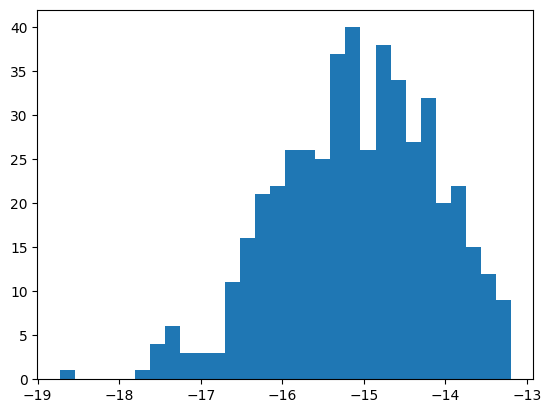

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# копия из клеток выше
data1 = np.random.normal(loc=-15, scale=1, size=500)
data2 = np.random.normal(loc=1, scale=1, size=100)
data = np.hstack([data1, data2])

print("original mean:", np.mean(data), "std:", np.std(data))

filtered = data[data <= np.percentile(data, 80)]
print("filtered mean:", np.mean(filtered), "std:", np.std(filtered))

plt.hist(filtered, bins=30)
plt.show()